In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation

2D heat equation solver
Done!


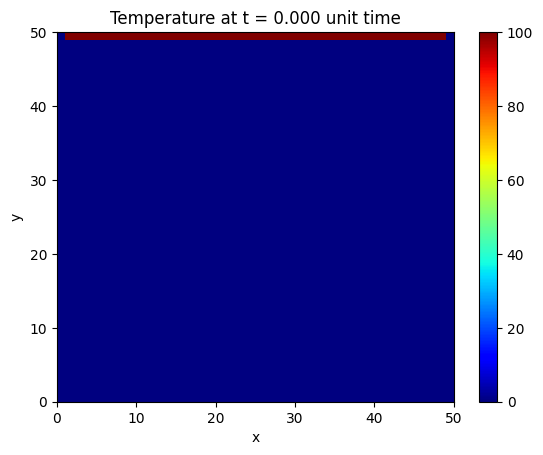

In [ ]:
print("2D heat equation solver")

plate_length = 50
max_iter_time = 750

alpha = 2
delta_x = 1

delta_t = (delta_x ** 2)/(4 * alpha)
gamma = (alpha * delta_t) / (delta_x ** 2)

# Initialize solution: the grid of u(k, i, j)
u = np.empty((max_iter_time, plate_length, plate_length))

# Initial condition everywhere inside the grid
u_initial = 0

# Boundary conditions
u_top = 100.0
u_left = 0.0
u_bottom = 0.0
u_right = 0.0

# Set the initial condition
u.fill(u_initial)

# Set the boundary conditions
u[:, (plate_length-1):, :] = u_top
u[:, :, :1] = u_left
u[:, :1, 1:] = u_bottom
u[:, :, (plate_length-1):] = u_right

def calculate(u):
    for k in range(0, max_iter_time-1, 1):
        for i in range(1, plate_length-1, delta_x):
            for j in range(1, plate_length-1, delta_x):
                u[k + 1, i, j] = gamma * (u[k][i+1][j] + u[k][i-1][j] + u[k][i][j+1] + u[k][i][j-1] - 4*u[k][i][j]) + u[k][i][j]

    return u

def plotheatmap(u_k, k):
    # Clear the current plot figure
    plt.clf()

    plt.title(f"Temperature at t = {k*delta_t:.3f} unit time")
    plt.xlabel("x")
    plt.ylabel("y")

    # This is to plot u_k (u at time-step k)
    plt.pcolormesh(u_k, cmap=plt.cm.jet, vmin=0, vmax=100)
    plt.colorbar()

    return plt

# Do the calculation here
u = calculate(u)

def animate(k):
    plotheatmap(u[k], k)

anim = animation.FuncAnimation(plt.figure(), animate, interval=1, frames=max_iter_time, repeat=False)
anim.save("heat_equation_solution.gif", fps=30)

print("Done!")

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.linalg import solve_banded

def solve_heat_ADI(size = (3.0, 3.0), grid_points = (60, 60), 
                   k_x = 1.25, k_y = 1.25, density = 1, specific_heat = 1, total_time = 4320.0, dt = 10.0,
                   boundary_temp = -17.778):
    '''
    Função para resolver a equação do calor 2D usando o método ADI (Alternating Direction Implicit)
    Todas as unidades são convertidas para SI (embora os parâmetros de entrada dos materiais não estejam)
    '''
    
    num_x, num_y = grid_points
    
    alpha_x = k_x / (density * specific_heat) * 1/3600 # Converte de m^2/h para m^2/s
    alpha_y = k_y / (density * specific_heat) * 1/3600 # Converte de m^2/h para m^2/s
    
    # Parâmetros gerais
    dx = size[0] / (num_x - 1)
    dy = size[1] / (num_y - 1)

    d1 = alpha_x * (dt / 2.0) / (dx**2)
    d2 = alpha_y * (dt / 2.0) / (dy**2)
    
    initial_temp = -1.111 # 30ºF convertidos pra ºC (direto da malásia)
    
    # Já inicializa tudo com a temp. de contorno e depois preenche o resto
    u = np.full(grid_points, boundary_temp)
    u[1:-1, 1:-1] = initial_temp
    
    
    # Inicializa a matriz auxiliar pro implícito em X
    A_x = np.zeros((3, num_x - 2))
    A_x[0, 1:] = -d1           # Diagonal superior
    A_x[1, :]  = 1 + 2 * d1    # Diagonal principal
    A_x[2, :-1] = -d1          # Diagonal inferior

    # Inicializa a matriz auxiliar pro implícito em Y
    A_y = np.zeros((3, num_y - 2))
    A_y[0, 1:] = -d2           # Diagonal superior
    A_y[1, :]  = 1 + 2 * d2    # Diagonal principal
    A_y[2, :-1] = -d2          # Diagonal inferior
    
    # Avançamos e guardamos cada estado da simulação
    states = [] 

    # Estado inicial
    states.append(u.copy())

    u_half = np.zeros_like(u) # Estado em n + 1/2

    # Passa em cada passo de tempo até completar o tempo total
    for n in range(int(total_time / dt)):
        # Congela o eixo y e resolve implicitamente em x
        for j in range(1, num_y - 1):
            # Resolve o lado direito da equação (dado por D1)
            D1 = np.zeros(num_x - 2)
            for i in range(1, num_x - 1):
                D1[i-1] = d2 * u[i, j+1] + (1 - 2*d2) * u[i, j] + d2 * u[i, j-1]

            # Adiciona condições de contorno
            D1[0] += d1 * u[0, j]
            D1[-1] += d1 * u[-1, j]
            
            # Resolve os sistemas tridiagonais pras linhas
            u_half[1:-1, j] = solve_banded((1, 1), A_x, D1)
            
        # Reforça as condições de contorno
        u_half[0, :] = u[0, :]
        u_half[-1, :] = u[-1, :]
        u_half[:, 0] = u[:, 0]
        u_half[:, -1] = u[:, -1]


        # Congela o eixo x e resolve implicitamente em y
        for i in range(1, num_x - 1):
            # Resolve o lado direito da equação (dado por D2)
            D2 = np.zeros(num_y - 2)
            for j in range(1, num_y - 1):
                D2[j-1] = d1 * u_half[i+1, j] + (1 - 2*d1) * u_half[i, j] + d1 * u_half[i-1, j]

            # Adiciona condições de contorno
            D2[0] += d2 * u_half[i, 0]
            D2[-1] += d2 * u_half[i, -1]
            
            # Resolve os sistemas tridiagonais pras colunas
            u[i, 1:-1] = solve_banded((1, 1), A_y, D2)

        # Armazena a matriz a cada passo de tempo para o GIF
        states.append(u.copy())

    return states

In [10]:
states = solve_heat_ADI()

In [21]:
def heat_semianalitycal_solution(x, y, t, Lx=3.0, Ly=3.0, kx=1.25, ky=1.25, termos=1000):
    ''' 
    Solução semianalítica da equação do calor 2D usando a série de Fourier, 
    considerando condições de contorno de Dirichlet. Pelas unidades usadas,
    as unidades de espaço e tempo são, respectivamente, metros e horas. 
    A temperatura é dada em ºC.
    '''
    
    temperature = 0
    
    # Caso x ou j sejam pares, o termo da soma é zero
    for n in range(1, termos+1, 2):
        for j in range(1, termos+1, 2):
            
            A_n = 120 / (n * j * np.pi**2) * 4
            
            temperature += A_n * np.sin(n * np.pi * x / Lx) * np.sin(j * np.pi * y / Ly) * \
                            np.exp(-((n**2 * kx / Lx**2 + j**2 * ky / Ly**2) * (np.pi**2) * t))
    
    return (temperature - 32) * 5/9 # Converte de ºF para ºC

In [20]:
print(heat_semianalitycal_solution(1.5, 1.5, 1.2, termos=1000))
print(heat_semianalitycal_solution(1.5, 0.3, 1.2, termos=1000))

1.8120465800957788
0.559954489267416


In [ ]:
frames = states

fig, ax = plt.subplots(figsize=(6, 5))
# Transpomos (frames[0].T) para que X fique no eixo horizontal do plot
cax = ax.imshow(frames[0].T, cmap='inferno', origin='upper', extent=[0, 3, 0, 3], vmin=-50, vmax=0)
ax.set_title("Equação do Calor 2D - Método ADI\nTempo: 0.00s")
ax.set_xlabel("Eixo X")
ax.set_ylabel("Eixo Y")
fig.colorbar(cax, label="Temperatura")

def animate(i):
    cax.set_array(frames[i].T)
    ax.set_title(f"Equação do Calor 2D - Método ADI\nTempo: {i * 10.0:.2f}s")
    return cax,

# Cria a animação
ani = animation.FuncAnimation(fig, animate, frames=len(frames), interval=50, blit=False)

# Salva como GIF (Requer a biblioteca Pillow, instalada com o matplotlib)
ani.save('calor_2d_adi.gif', fps=15)
print("GIF salvo com sucesso como 'calor_2d_adi.gif'!")